In [12]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INDIR = 'gev_xi_lmom'         # --outdir from the compute run
TAG   = 'v1'                  # --tag from the compute run
ESTIMATOR = 'lmom'            
MASTER_SEED = 20260726        # repetable seed, using the original date of the notebook

XI_REFERENCE = 0.114          # pooled-observation value, P&K (2013)
XI_WILD      = 1.5            # threshold for calling an estimate implausible
YCLIP        = 1.5            # figure y-limit; choose from the clip table

CITIES = ['albany', 'amarillo', 'grand_junction', 'minneapolis',
          'nashville', 'phoenix', 'seattle', 'tallahassee']
DURATIONS = ['15min', '24hr']

In [13]:
#cells = pd.read_csv(os.path.join(INDIR, f'gev_xi_cells_{TAG}.csv'))

cells = pd.read_csv(os.path.join(INDIR, f'gev_xi_cells_{TAG}_{ESTIMATOR}.csv')) #filename now carries the estimator suffix
print(f"{len(cells)} cell-duration records")

# all raw bootstrap draws, keyed by cell -> 1D array of 500 (NaN = failed refit)
draws = {}
for city in CITIES:
    for dur in DURATIONS:
        f = os.path.join(INDIR, f'{city}__{dur}_boot.npz')
        if not os.path.exists(f):
            print(f"missing: {f}")
            continue
        z = np.load(f)
        for k, (i, j) in enumerate(z['ij']):
            draws[(city, dur, int(i), int(j))] = z['draws'][k]
print(f"{len(draws)} bootstrap arrays loaded")

400 cell-duration records
400 bootstrap arrays loaded


In [14]:
ok = cells[cells.outcome == 'ok'].copy()

ok['half_width']    = (ok.xi_hi - ok.xi_lo) / 2.0
ok['contains_0']    = ((ok.xi_lo <= 0) & (0 <= ok.xi_hi)).astype(float)
ok['contains_ref']  = ((ok.xi_lo <= XI_REFERENCE) & (XI_REFERENCE <= ok.xi_hi)).astype(float)
ok['contains_both'] = ok.contains_0 * ok.contains_ref
ok['point_wild']    = (ok.xi.abs() > XI_WILD).astype(float)

def _frac_wild(r):
    d = draws.get((r.city, r.duration, r.i, r.j))
    if d is None:
        return np.nan
    d = d[np.isfinite(d)]
    return float(np.mean(np.abs(d) > XI_WILD)) if len(d) else np.nan

ok['boot_frac_wild'] = [_frac_wild(r) for r in ok.itertuples()]
ok.head()

,city,duration,i,j,n_years,estimator,xi,n_boot_ok,outcome,xi_lo,xi_hi,half_width,contains_0,contains_ref,contains_both,point_wild,boot_frac_wild
0,albany,15min,0,0,15,lmom,0.299041,1000,ok,-0.160715,0.564113,0.362414,1.0,1.0,1.0,0.0,0.0
1,albany,15min,0,5,15,lmom,0.230225,1000,ok,-0.460690,0.494402,0.477546,1.0,1.0,1.0,0.0,0.0
2,albany,15min,0,10,15,lmom,-0.140758,1000,ok,-0.577336,0.187973,0.382655,1.0,1.0,1.0,0.0,0.0
3,albany,15min,0,15,15,lmom,-0.137822,1000,ok,-0.811912,0.211218,0.511565,1.0,1.0,1.0,0.0,0.0
4,albany,15min,0,20,15,lmom,0.003415,1000,ok,-0.455374,0.280364,0.367869,1.0,1.0,1.0,0.0,0.0


In [15]:
# Verify complete data
ORDER = ['too_few_years', 'fit_failed', 'bootstrap_failed', 'ok']
acct = cells.groupby(['city','duration','outcome']).size().unstack('outcome', fill_value=0)
for c in ORDER:
    if c not in acct: acct[c] = 0
acct = acct[ORDER]
acct['total'] = acct.sum(axis=1)
print(acct.reset_index().to_string(index=False))
assert (acct.total == 25).all(), "accounting does not close"

          city duration  too_few_years  fit_failed  bootstrap_failed  ok  total
        albany    15min              0           0                 0  25     25
        albany     24hr              0           0                 0  25     25
      amarillo    15min              0           0                 0  25     25
      amarillo     24hr              0           0                 0  25     25
grand_junction    15min              0           0                 0  25     25
grand_junction     24hr              0           0                 0  25     25
   minneapolis    15min              0           0                 0  25     25
   minneapolis     24hr              0           0                 0  25     25
     nashville    15min              0           0                 0  25     25
     nashville     24hr              0           0                 0  25     25
       phoenix    15min              0           0                 0  25     25
       phoenix     24hr              0  

In [16]:
summ = (ok.groupby(['city','duration'])
          .agg(n=('xi','size'),
               med_hw=('half_width','median'),
               max_hw=('half_width','max'),
               pct_both=('contains_both', lambda v: 100*v.mean()),
               pct_zero=('contains_0',    lambda v: 100*v.mean()),
               pct_wild=('point_wild',    lambda v: 100*v.mean()),
               med_boot_wild=('boot_frac_wild','median'))
          .round(3))
print(summ.reset_index().to_string(index=False))

          city duration  n  med_hw  max_hw  pct_both  pct_zero  pct_wild  med_boot_wild
        albany    15min 25   0.453   0.569      92.0      92.0       0.0            0.0
        albany     24hr 25   0.424   0.558     100.0     100.0       0.0            0.0
      amarillo    15min 25   0.462   0.697      80.0      92.0       0.0            0.0
      amarillo     24hr 25   0.446   0.540      84.0     100.0       0.0            0.0
grand_junction    15min 25   0.450   0.662      96.0     100.0       0.0            0.0
grand_junction     24hr 25   0.416   0.688      88.0      96.0       0.0            0.0
   minneapolis    15min 25   0.450   0.553      88.0     100.0       0.0            0.0
   minneapolis     24hr 25   0.423   0.665      92.0      96.0       0.0            0.0
     nashville    15min 25   0.438   0.609      80.0     100.0       0.0            0.0
     nashville     24hr 25   0.403   0.527      96.0     100.0       0.0            0.0
       phoenix    15min 25   0.4

In [17]:
print(f"1. cells fit: {len(ok)} of {len(cells)}")
bad = cells[cells.outcome != 'ok']
if len(bad):
    print("   failures:", bad.outcome.value_counts().to_dict())
    print(bad.groupby(['city','duration']).size().to_string())

print("\n2. median half-width of the 95% interval on xi")
print(ok.groupby('duration').half_width.median().round(3).to_string())
med = ok.half_width.median()
print(f"   overall {med:.3f}  ->  {med/XI_REFERENCE:.1f}x the xi={XI_REFERENCE} being measured")

print(f"\n3. interval contains BOTH 0 and {XI_REFERENCE}: {100*ok.contains_both.mean():.1f}%")
print(ok.groupby('duration').contains_both.mean().mul(100).round(1).to_string())
print(f"   (0 alone {100*ok.contains_0.mean():.1f}%, {XI_REFERENCE} alone {100*ok.contains_ref.mean():.1f}%)")

print(f"\n4. point estimates with |xi| > {XI_WILD}")
print(ok.groupby('duration').point_wild.mean().mul(100).round(1).to_string())
print(f"   largest |xi| observed: {ok.xi.abs().max():.2f}")

print(f"\n5. median fraction of refits landing at |xi| > {XI_WILD}")
print(ok.groupby('duration').boot_frac_wild.median().round(3).to_string())

print("\nclip table (pick YCLIP):")
for y in (1.5, 2.0, 2.5, 3.0, 5.0):
    n_pt = int((ok.xi.abs() > y).sum())
    n_ci = int(((ok.xi_hi > y) | (ok.xi_lo < -y)).sum())
    print(f"   +/-{y}: {n_pt} points, {n_ci} interval ends clipped")

1. cells fit: 400 of 400

2. median half-width of the 95% interval on xi
duration
15min    0.437
24hr     0.426
   overall 0.429  ->  3.8x the xi=0.114 being measured

3. interval contains BOTH 0 and 0.114: 89.2%
duration
15min    89.0
24hr     89.5
   (0 alone 97.2%, 0.114 alone 89.5%)

4. point estimates with |xi| > 1.5
duration
15min    0.0
24hr     0.0
   largest |xi| observed: 0.66

5. median fraction of refits landing at |xi| > 1.5
duration
15min    0.0
24hr     0.0

clip table (pick YCLIP):
   +/-1.5: 0 points, 0 interval ends clipped
   +/-2.0: 0 points, 0 interval ends clipped
   +/-2.5: 0 points, 0 interval ends clipped
   +/-3.0: 0 points, 0 interval ends clipped
   +/-5.0: 0 points, 0 interval ends clipped


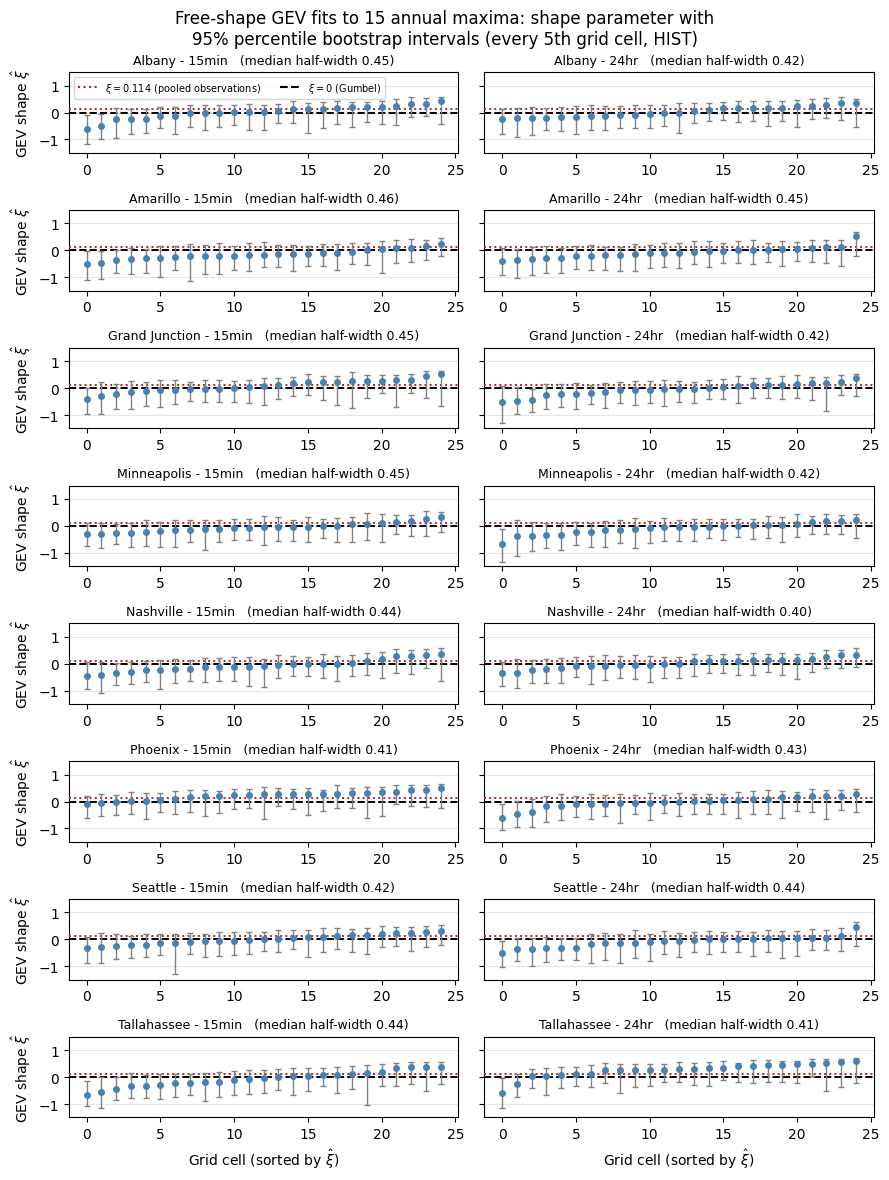

In [21]:
fig, axes = plt.subplots(len(CITIES), len(DURATIONS), figsize=(9, 12),
                         sharey=True, squeeze=False)

for r, city in enumerate(CITIES):
    for c, dur in enumerate(DURATIONS):
        ax = axes[r][c]
        g = ok[(ok.city == city) & (ok.duration == dur)].sort_values('xi')
        x = np.arange(len(g))
        ax.errorbar(x, g.xi, yerr=[g.xi - g.xi_lo, g.xi_hi - g.xi],
                    fmt='o', ms=4, color='steelblue', ecolor='gray',
                    elinewidth=1, capsize=2, zorder=10)
        ax.axhline(XI_REFERENCE, color='firebrick', ls=':', lw=1.4, zorder=5)
        ax.axhline(0, color='black', ls='--', lw=1.4, zorder=5)
        ax.set_ylim(-YCLIP, YCLIP)
        hw = summ.loc[(city, dur), 'med_hw'] if (city, dur) in summ.index else np.nan
        ax.set_title(f"{city.replace('_',' ').title()} - {dur}   "
                     f"(median half-width {hw:.2f})", fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if c == 0: ax.set_ylabel(r'GEV shape $\hat{\xi}$')
        if r == len(CITIES)-1: ax.set_xlabel(r'Grid cell (sorted by $\hat{\xi}$)')

axes[0][0].plot([], [], 'k--', label=r'$\xi=0$ (Gumbel)')
axes[0][0].plot([], [], ':', color='firebrick',
                label=rf'$\xi={XI_REFERENCE}$ (pooled observations)')

handles, labels = axes[0][0].get_legend_handles_labels()
axes[0][0].legend(handles[::-1], labels[::-1], fontsize=7, loc='upper left', ncol=2) #reverse the order of the legend items so they fit better

#axes[0][0].legend(fontsize=7, loc='upper left')

plt.suptitle('Free-shape GEV fits to 15 annual maxima: shape parameter with\n'
             '95% percentile bootstrap intervals (every 5th grid cell, HIST)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'gev_shape_check_{TAG}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'gev_shape_check_{TAG}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print(f"seed = {MASTER_SEED}")
print("percentile bootstrap, 1000 resamples, no filtering of estimates")
print(f"y-limits +/-{YCLIP}: {int((ok.xi.abs()>YCLIP).sum())} points and "
      f"{int(((ok.xi_hi>YCLIP)|(ok.xi_lo<-YCLIP)).sum())} interval ends clipped")
print("exclusions:", acct[['too_few_years','fit_failed','bootstrap_failed']].sum().to_dict())
print(f"reference lines at 0 and {XI_REFERENCE}")

seed = 20260726
percentile bootstrap, 1000 resamples, no filtering of estimates
y-limits +/-1.5: 0 points and 0 interval ends clipped
exclusions: {'too_few_years': 0, 'fit_failed': 0, 'bootstrap_failed': 0}
reference lines at 0 and 0.114


In [23]:
import pandas as pd, numpy as np

frames = {}
for est, d in [('mle', 'gev_xi_out'), ('lmom', 'gev_xi_lmom')]:
    fn = f'{d}/gev_xi_cells_v1_{est}.csv'
    if not os.path.exists(fn):                      # MLE run predates the suffix
        fn = f'{d}/gev_xi_cells_v1.csv'
    df = pd.read_csv(fn)
    df = df[df.outcome == 'ok'].copy()
    df['half_width'] = (df.xi_hi - df.xi_lo) / 2
    df['both'] = (((df.xi_lo <= 0) & (0 <= df.xi_hi)) &
                  ((df.xi_lo <= 0.114) & (0.114 <= df.xi_hi))).astype(float)
    frames[est] = df

for est, df in frames.items():
    print(f"\n{est.upper()}  (n = {len(df)})")
    print(f"  median half-width : "
          f"{df[df.duration=='15min'].half_width.median():.3f} (15min), "
          f"{df[df.duration=='24hr'].half_width.median():.3f} (24hr)")
    print(f"  contains 0 & 0.114: {100*df.both.mean():.1f}%")
    print(f"  ratio to range 0.23: "
          f"{df.half_width.median()*2/0.23:.1f}x")
    print(f"  median xi_hat     : {df.xi.median():+.3f}   "
          f"|xi| max: {df.xi.abs().max():.2f}")


MLE  (n = 400)
  median half-width : 3.935 (15min), 1.611 (24hr)
  contains 0 & 0.114: 97.8%
  ratio to range 0.23: 30.8x
  median xi_hat     : +0.022   |xi| max: 6.40

LMOM  (n = 400)
  median half-width : 0.437 (15min), 0.426 (24hr)
  contains 0 & 0.114: 89.2%
  ratio to range 0.23: 3.7x
  median xi_hat     : -0.009   |xi| max: 0.66
